In [1]:
import warnings, textwrap
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4a",
    "axes.labelcolor":  "#e0e0e0",
    "text.color":       "#e0e0e0",
    "xtick.color":      "#b0b0b0",
    "ytick.color":      "#b0b0b0",
    "grid.color":       "#2e3140",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.5,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "legend.framealpha": 0.3,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4a",
})

PALETTE = ["#7c83fd","#f9c74f","#90be6d","#f94144","#43aa8b","#f8961e","#577590","#a8dadc"]
ACCENT, ACCENT2, SUCCESS, DANGER = "#7c83fd", "#f9c74f", "#90be6d", "#f94144"

def style_ax(ax, title="", xlabel="", ylabel="", grid="y"):
    ax.set_title(title, fontsize=12, fontweight="bold", color="#ffffff", pad=10)
    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.spines[["top","right"]].set_visible(False)
    if grid == "y":     ax.yaxis.grid(True, alpha=0.3)
    elif grid == "x":   ax.xaxis.grid(True, alpha=0.3)
    elif grid == "both": ax.yaxis.grid(True, alpha=0.3); ax.xaxis.grid(True, alpha=0.3)
    return ax

In [2]:
df = pd.read_excel("rideBookings_preprocessed1.xlsx")
df["Datetime"]  = pd.to_datetime(df["Datetime"])
df["DayName"]   = df["DayOfWeek"].map({0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"})
df["MonthName"] = df["Month"].map({1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                                    7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"})
print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")

Shape      : (148767, 31)
Date range : 2024-01-01 → 2024-12-30


In [3]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Total rows         : {len(df):,}")
print(f"  Total columns      : {df.shape[1]}")
print(f"  Numeric columns    : {df.select_dtypes(include='number').shape[1]}")
print(f"  Categorical columns: {df.select_dtypes(include='object').shape[1]}")
print(f"  Date range         : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Duplicate rows     : {df.duplicated().sum()}")
print()
print(df.dtypes.to_string())

  DATASET OVERVIEW
  Total rows         : 148,767
  Total columns      : 31
  Numeric columns    : 16
  Categorical columns: 13
  Date range         : 2024-01-01 → 2024-12-30
  Duplicate rows     : 0

Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Re

,Missing Count,Missing %,Present Count
Incomplete Rides,139840,94.00,8927
Incomplete Rides Reason,139840,94.00,8927
Cancelled Rides by Customer,138365,93.01,10402
Reason for cancelling by Customer,138365,93.01,10402
Cancelled Rides by Driver,121978,81.99,26789
Driver Cancellation Reason,121978,81.99,26789
Driver Ratings,56519,37.99,92248
Customer Rating,56519,37.99,92248
Booking Value,47592,31.99,101175
Ride Distance,47592,31.99,101175


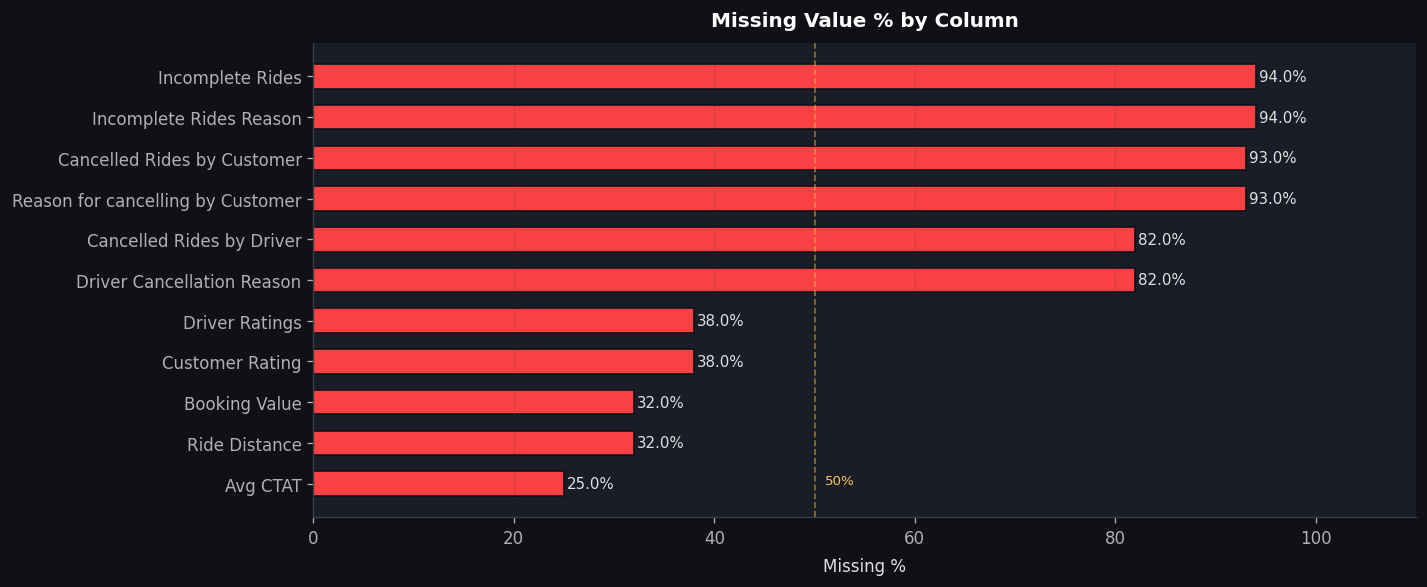

In [4]:
missing       = df.isnull().sum()
missing_pct   = (missing / len(df) * 100).round(2)
missing_df    = pd.DataFrame({
    "Missing Count": missing,
    "Missing %":     missing_pct,
    "Present Count": len(df) - missing,
}).sort_values("Missing Count", ascending=False)

display(missing_df[missing_df["Missing Count"] > 0])

# Visual
fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0f1117")
cols_with_missing = missing_df[missing_df["Missing Count"] > 0]
bars = ax.barh(cols_with_missing.index[::-1], cols_with_missing["Missing %"][::-1],
               color=DANGER, edgecolor="#0f1117", height=0.6)
for bar, v in zip(bars, cols_with_missing["Missing %"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va="center", fontsize=9, color="#e0e0e0")
style_ax(ax, "Missing Value % by Column", "Missing %", "", grid="x")
ax.set_xlim(0, 110)
ax.axvline(50, color=ACCENT2, linestyle="--", alpha=0.5, linewidth=1)
ax.text(51, 0, "50%", color=ACCENT2, fontsize=8)
fig.tight_layout(); plt.show()

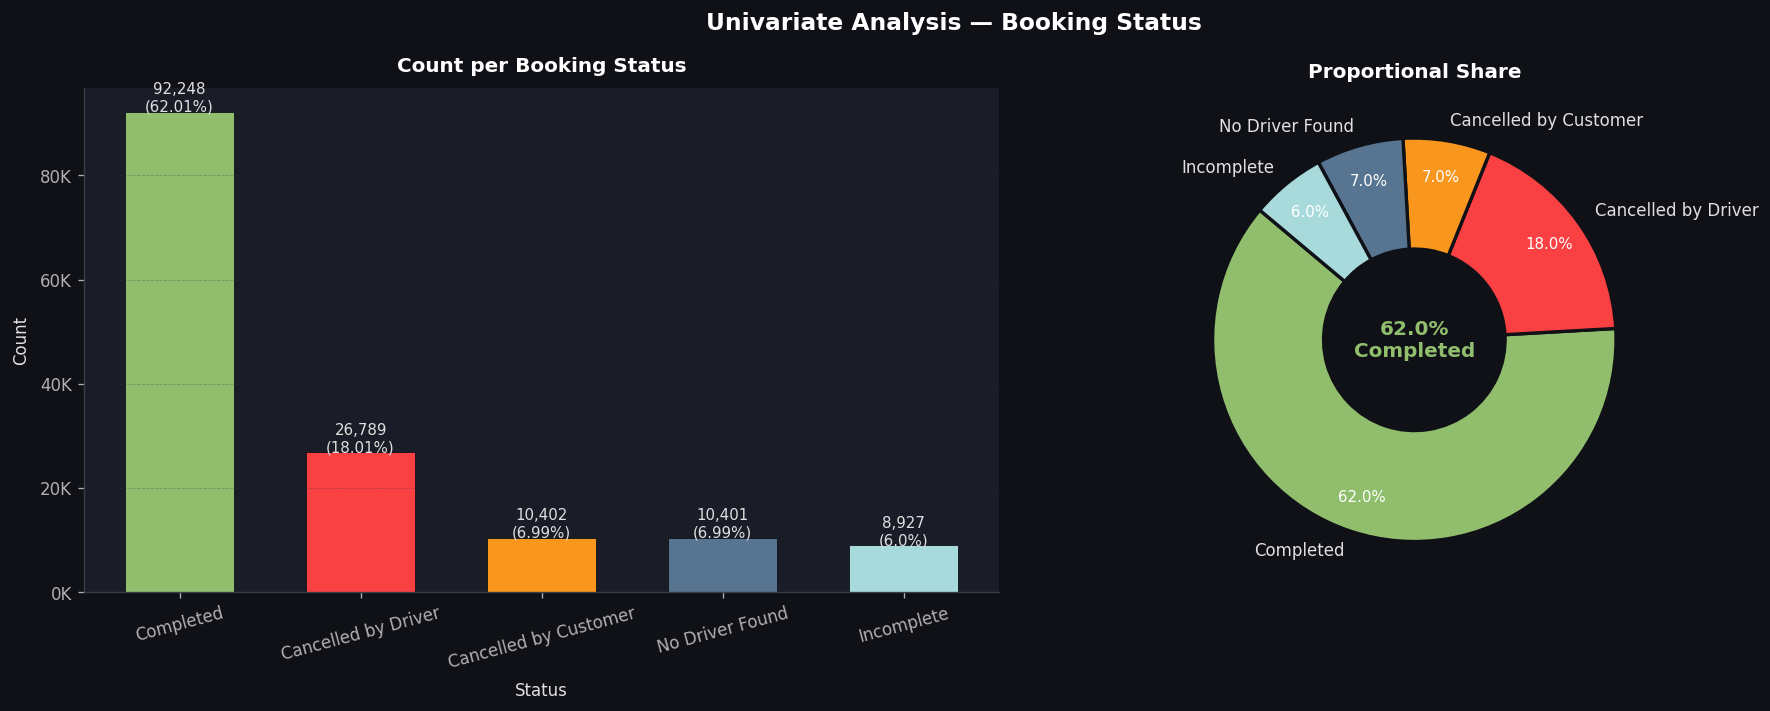


--- Booking Status Summary ---
                       Count  Percentage
Booking Status                          
Completed              92248       62.01
Cancelled by Driver    26789       18.01
Cancelled by Customer  10402        6.99
No Driver Found        10401        6.99
Incomplete              8927        6.00


In [5]:
status = df["Booking Status"].value_counts()
status_pct = (status / len(df) * 100).round(2)
status_colors = [SUCCESS, DANGER, "#f8961e", "#577590", "#a8dadc"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Booking Status", fontsize=14, fontweight="bold", color="#ffffff")

bars = axes[0].bar(status.index, status.values, color=status_colors,
                   edgecolor="#0f1117", linewidth=0.5, width=0.6)
for bar, val, pct in zip(bars, status.values, status_pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f"{val:,}\n({pct}%)", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[0], "Count per Booking Status", "Status", "Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[0].tick_params(axis="x", rotation=15)

wedges, texts, autotexts = axes[1].pie(
    status.values, labels=status.index, colors=status_colors,
    autopct="%1.1f%%", startangle=140, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor="#0f1117", linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color("white")
for t in texts: t.set_color("#e0e0e0")
axes[1].add_artist(plt.Circle((0,0), 0.45, fc="#0f1117"))
completed = (df["Booking Status"]=="Completed").sum()
axes[1].text(0, 0, f"{completed/len(df)*100:.1f}%\nCompleted",
             ha="center", va="center", fontsize=12, fontweight="bold", color=SUCCESS)
axes[1].set_title("Proportional Share", color="#ffffff", fontweight="bold")
fig.tight_layout(); plt.show()

print("\n--- Booking Status Summary ---")
print(pd.DataFrame({"Count": status, "Percentage": status_pct}).to_string())

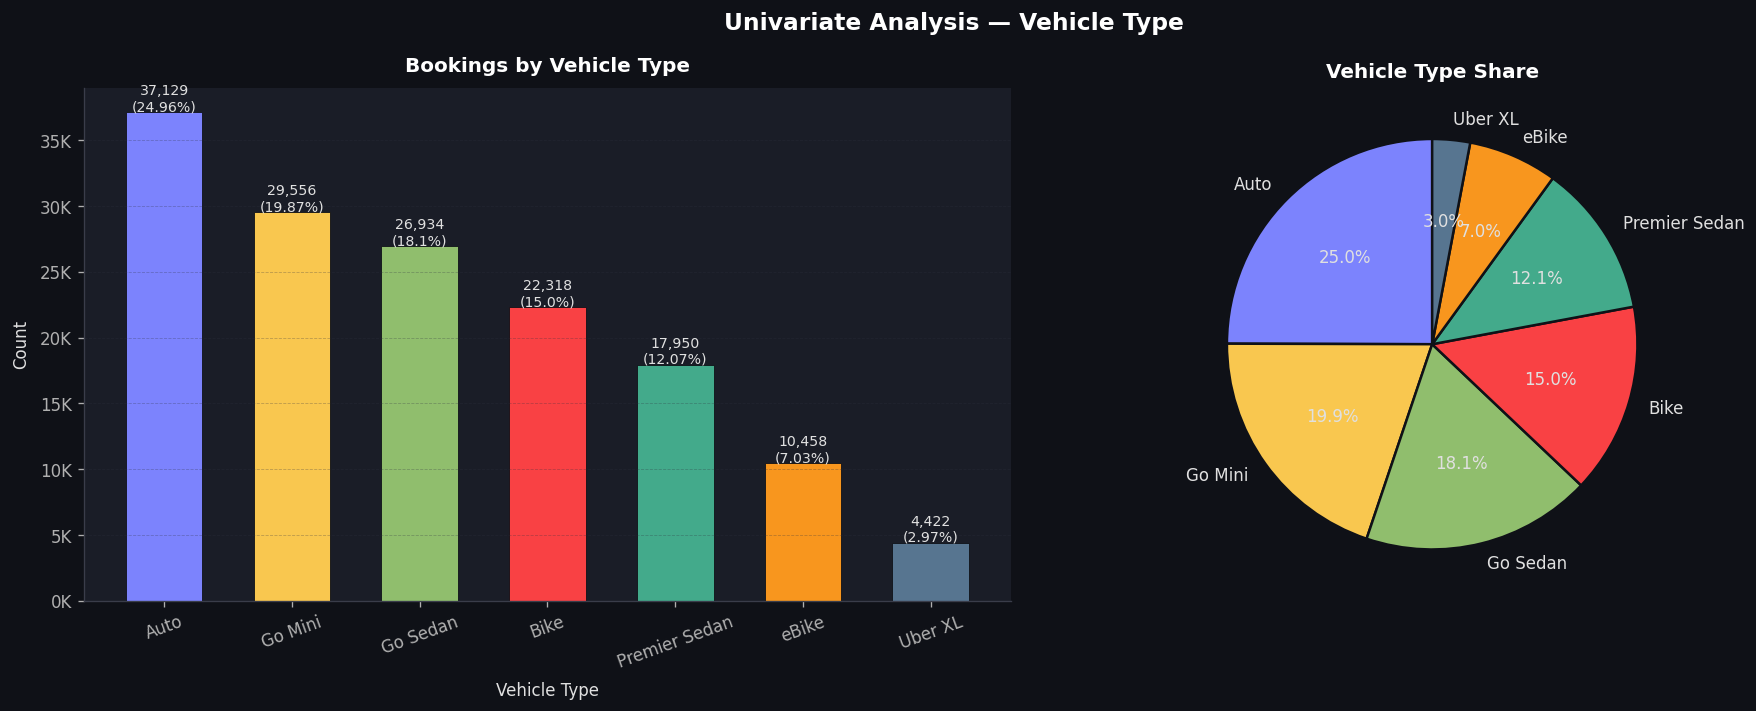


--- Vehicle Type Summary ---
               Count  Percentage
Vehicle Type                    
Auto           37129       24.96
Go Mini        29556       19.87
Go Sedan       26934       18.10
Bike           22318       15.00
Premier Sedan  17950       12.07
eBike          10458        7.03
Uber XL         4422        2.97


In [6]:
vt     = df["Vehicle Type"].value_counts()
vt_pct = (vt / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Vehicle Type", fontsize=14, fontweight="bold", color="#ffffff")

bars = axes[0].bar(vt.index, vt.values, color=PALETTE[:len(vt)],
                   edgecolor="#0f1117", linewidth=0.5, width=0.6)
for bar, val, pct in zip(bars, vt.values, vt_pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{val:,}\n({pct}%)", ha="center", fontsize=8.5, color="#e0e0e0")
style_ax(axes[0], "Bookings by Vehicle Type", "Vehicle Type", "Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[0].tick_params(axis="x", rotation=20)

axes[1].pie(vt.values, labels=vt.index, colors=PALETTE[:len(vt)],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[1].set_title("Vehicle Type Share", color="#ffffff", fontweight="bold")
fig.tight_layout(); plt.show()

print("\n--- Vehicle Type Summary ---")
print(pd.DataFrame({"Count": vt, "Percentage": vt_pct}).to_string())

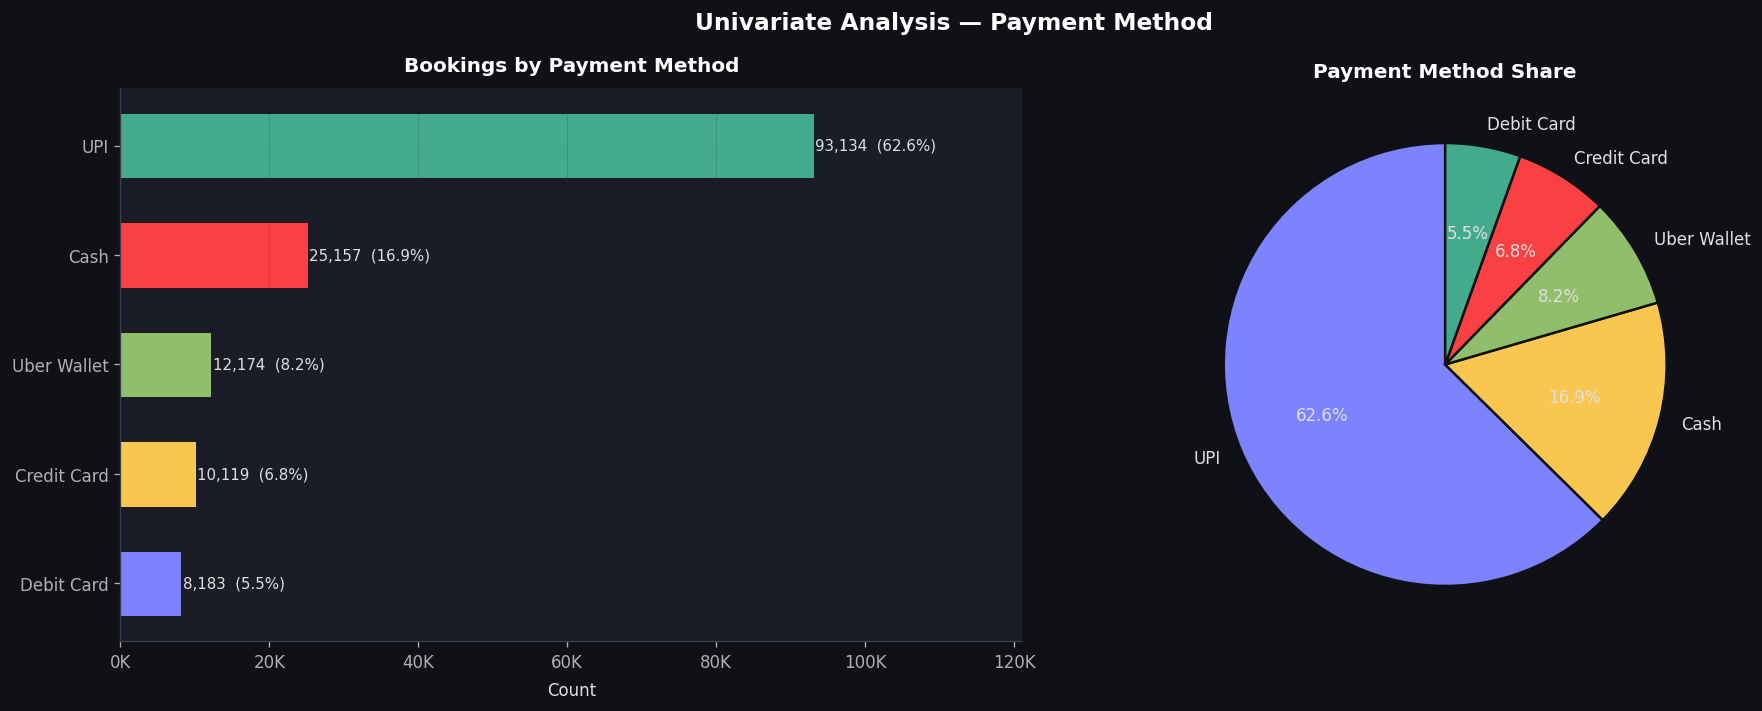


--- Payment Method Summary ---
                Count  Percentage
Payment Method                   
UPI             93134       62.60
Cash            25157       16.91
Uber Wallet     12174        8.18
Credit Card     10119        6.80
Debit Card       8183        5.50


In [7]:
pay     = df["Payment Method"].value_counts()
pay_pct = (pay / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Payment Method", fontsize=14, fontweight="bold", color="#ffffff")

bars = axes[0].barh(pay.index[::-1], pay.values[::-1],
                    color=PALETTE[:len(pay)], edgecolor="#0f1117", linewidth=0.5, height=0.6)
for bar, val in zip(bars, pay.values[::-1]):
    axes[0].text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
                 f"{val:,}  ({val/len(df)*100:.1f}%)", va="center", fontsize=9, color="#e0e0e0")
style_ax(axes[0], "Bookings by Payment Method", "Count", "", grid="x")
axes[0].set_xlim(0, pay.max()*1.3)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))

axes[1].pie(pay.values, labels=pay.index, colors=PALETTE[:len(pay)],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[1].set_title("Payment Method Share", color="#ffffff", fontweight="bold")
fig.tight_layout(); plt.show()

print("\n--- Payment Method Summary ---")
print(pd.DataFrame({"Count": pay, "Percentage": pay_pct}).to_string())

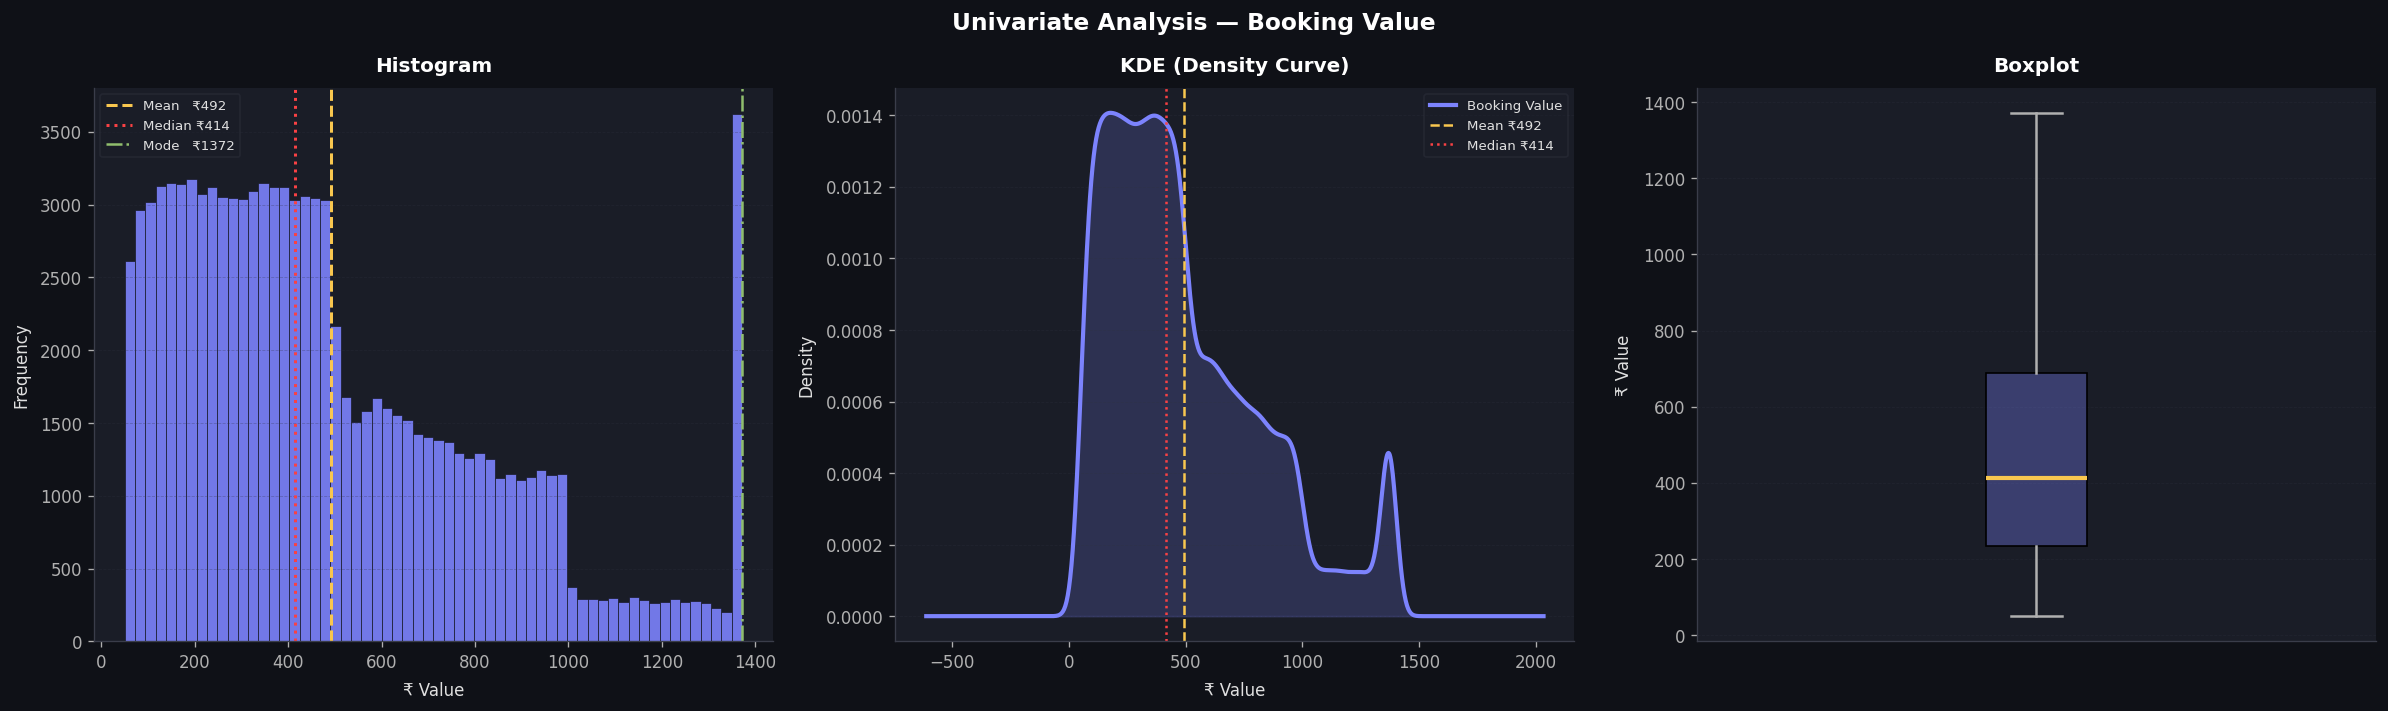


--- Booking Value Descriptive Statistics ---
count    101175.00
mean        492.00
std         331.73
min          50.00
25%         234.00
50%         414.00
75%         689.00
max        1371.50
Skewness  : 0.9428
Kurtosis  : 0.2585
IQR       : 455.00
Outliers  : 0 (0.00%)


In [8]:
bv = df["Booking Value"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Booking Value", fontsize=14, fontweight="bold", color="#ffffff")

# Histogram
axes[0].hist(bv, bins=60, color=ACCENT, edgecolor="#0f1117", linewidth=0.4, alpha=0.9)
axes[0].axvline(bv.mean(),   color=ACCENT2, linestyle="--", linewidth=1.8, label=f"Mean   ₹{bv.mean():.0f}")
axes[0].axvline(bv.median(), color=DANGER,  linestyle=":",  linewidth=1.8, label=f"Median ₹{bv.median():.0f}")
axes[0].axvline(bv.mode()[0],color=SUCCESS, linestyle="-.", linewidth=1.5, label=f"Mode   ₹{bv.mode()[0]:.0f}")
style_ax(axes[0], "Histogram", "₹ Value", "Frequency")
axes[0].legend(fontsize=8)

# KDE
bv.plot(kind="kde", ax=axes[1], color=ACCENT, linewidth=2.5)
axes[1].fill_between(axes[1].lines[0].get_xdata(),
                     axes[1].lines[0].get_ydata(), alpha=0.2, color=ACCENT)
axes[1].axvline(bv.mean(),   color=ACCENT2, linestyle="--", linewidth=1.5, label=f"Mean ₹{bv.mean():.0f}")
axes[1].axvline(bv.median(), color=DANGER,  linestyle=":",  linewidth=1.5, label=f"Median ₹{bv.median():.0f}")
style_ax(axes[1], "KDE (Density Curve)", "₹ Value", "Density")
axes[1].legend(fontsize=8)

# Boxplot
axes[2].boxplot(bv, vert=True, patch_artist=True,
                medianprops=dict(color=ACCENT2, linewidth=2.5),
                boxprops=dict(facecolor=ACCENT+"55"),
                whiskerprops=dict(color="#b0b0b0", linewidth=1.5),
                capprops=dict(color="#b0b0b0", linewidth=1.5),
                flierprops=dict(marker=".", alpha=0.3, color=DANGER, markersize=4))
style_ax(axes[2], "Boxplot", "", "₹ Value")
axes[2].set_xticks([])
fig.tight_layout(); plt.show()

print("\n--- Booking Value Descriptive Statistics ---")
print(bv.describe().round(2).to_string())
print(f"Skewness  : {bv.skew():.4f}")
print(f"Kurtosis  : {bv.kurtosis():.4f}")
Q1, Q3 = bv.quantile(0.25), bv.quantile(0.75)
IQR = Q3 - Q1
outliers = ((bv < Q1-1.5*IQR) | (bv > Q3+1.5*IQR)).sum()
print(f"IQR       : {IQR:.2f}")
print(f"Outliers  : {outliers} ({outliers/len(bv)*100:.2f}%)")

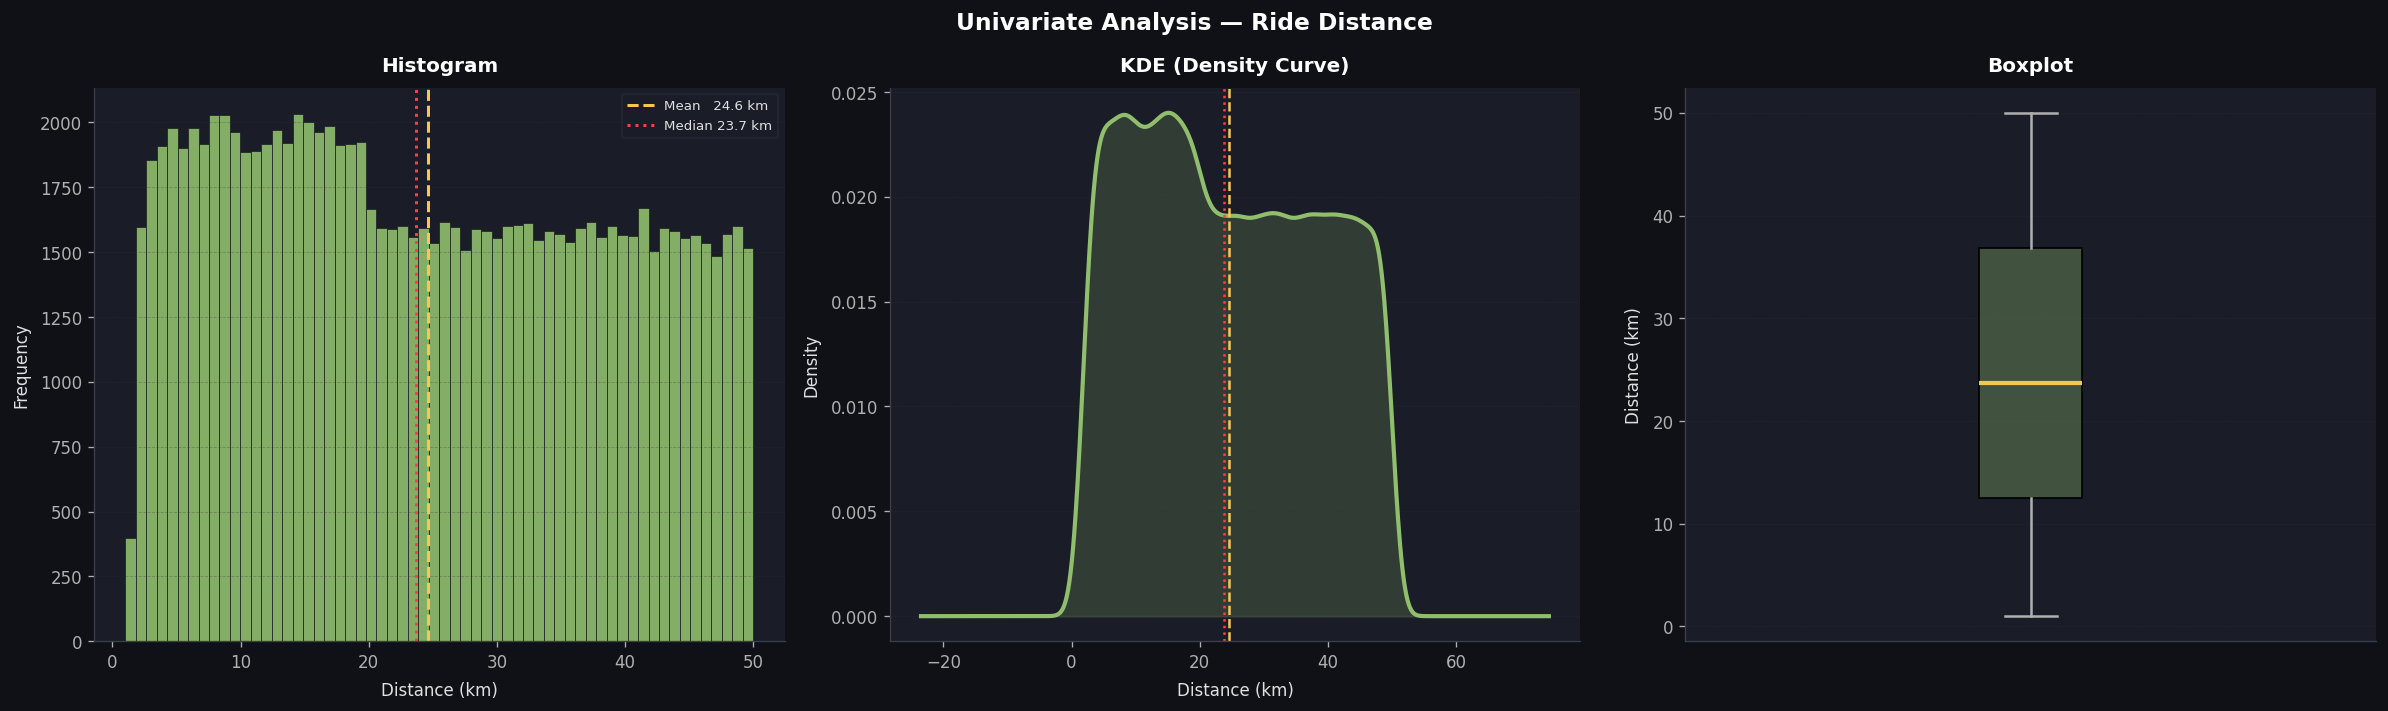


--- Ride Distance Descriptive Statistics ---
count    101175.00
mean         24.64
std          14.00
min           1.00
25%          12.46
50%          23.72
75%          36.82
max          50.00
Skewness  : 0.1279
Kurtosis  : -1.2126
IQR       : 24.36
Outliers  : 0 (0.00%)


In [9]:
rd = df["Ride Distance"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Ride Distance", fontsize=14, fontweight="bold", color="#ffffff")

axes[0].hist(rd, bins=60, color=SUCCESS, edgecolor="#0f1117", linewidth=0.4, alpha=0.9)
axes[0].axvline(rd.mean(),   color=ACCENT2, linestyle="--", linewidth=1.8, label=f"Mean   {rd.mean():.1f} km")
axes[0].axvline(rd.median(), color=DANGER,  linestyle=":",  linewidth=1.8, label=f"Median {rd.median():.1f} km")
style_ax(axes[0], "Histogram", "Distance (km)", "Frequency")
axes[0].legend(fontsize=8)

rd.plot(kind="kde", ax=axes[1], color=SUCCESS, linewidth=2.5)
axes[1].fill_between(axes[1].lines[0].get_xdata(),
                     axes[1].lines[0].get_ydata(), alpha=0.2, color=SUCCESS)
axes[1].axvline(rd.mean(),   color=ACCENT2, linestyle="--", linewidth=1.5)
axes[1].axvline(rd.median(), color=DANGER,  linestyle=":",  linewidth=1.5)
style_ax(axes[1], "KDE (Density Curve)", "Distance (km)", "Density")

axes[2].boxplot(rd, vert=True, patch_artist=True,
                medianprops=dict(color=ACCENT2, linewidth=2.5),
                boxprops=dict(facecolor=SUCCESS+"55"),
                whiskerprops=dict(color="#b0b0b0", linewidth=1.5),
                capprops=dict(color="#b0b0b0", linewidth=1.5),
                flierprops=dict(marker=".", alpha=0.3, color=DANGER, markersize=4))
style_ax(axes[2], "Boxplot", "", "Distance (km)")
axes[2].set_xticks([])
fig.tight_layout(); plt.show()

print("\n--- Ride Distance Descriptive Statistics ---")
print(rd.describe().round(2).to_string())
print(f"Skewness  : {rd.skew():.4f}")
print(f"Kurtosis  : {rd.kurtosis():.4f}")
Q1, Q3 = rd.quantile(0.25), rd.quantile(0.75)
IQR = Q3 - Q1
outliers = ((rd < Q1-1.5*IQR) | (rd > Q3+1.5*IQR)).sum()
print(f"IQR       : {IQR:.2f}")
print(f"Outliers  : {outliers} ({outliers/len(rd)*100:.2f}%)")

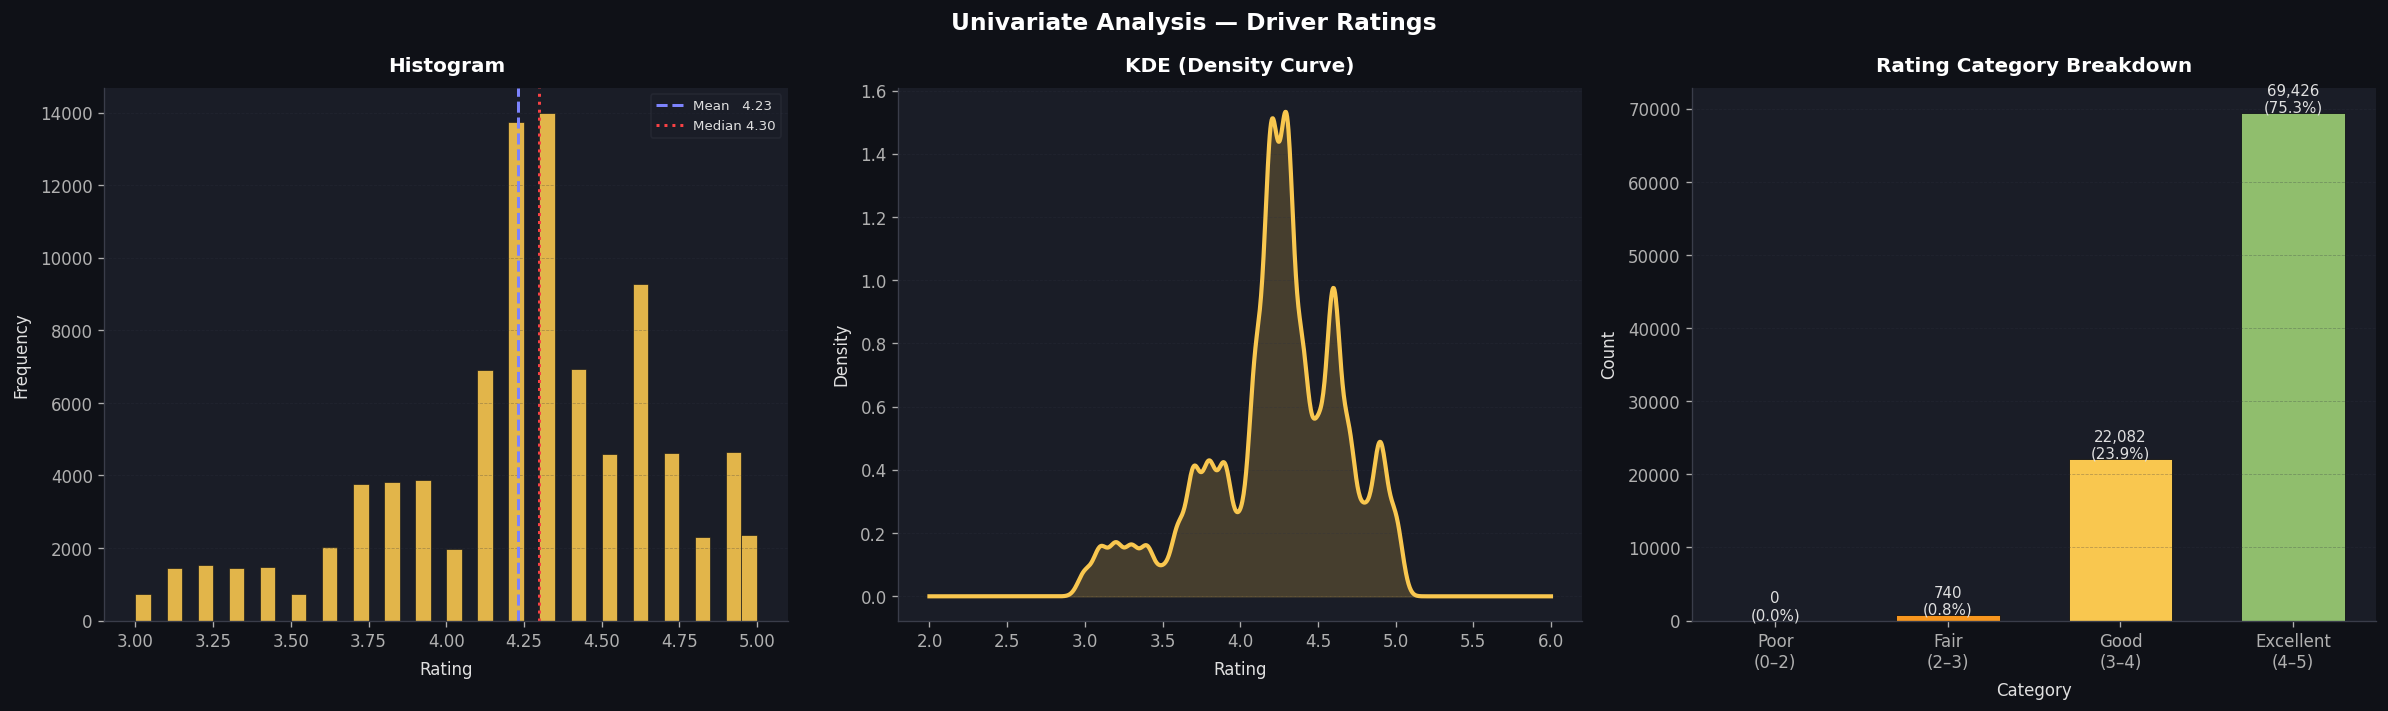


--- Driver Ratings Descriptive Statistics ---
count    92248.000
mean         4.231
std          0.437
min          3.000
25%          4.100
50%          4.300
75%          4.600
max          5.000
Skewness  : -0.6558
Kurtosis  : 0.2822


In [10]:
dr = df["Driver Ratings"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Driver Ratings", fontsize=14, fontweight="bold", color="#ffffff")

axes[0].hist(dr, bins=40, color=ACCENT2, edgecolor="#0f1117", linewidth=0.4, alpha=0.9)
axes[0].axvline(dr.mean(),   color=ACCENT, linestyle="--", linewidth=1.8, label=f"Mean   {dr.mean():.2f}")
axes[0].axvline(dr.median(), color=DANGER, linestyle=":",  linewidth=1.8, label=f"Median {dr.median():.2f}")
style_ax(axes[0], "Histogram", "Rating", "Frequency")
axes[0].legend(fontsize=8)

dr.plot(kind="kde", ax=axes[1], color=ACCENT2, linewidth=2.5)
axes[1].fill_between(axes[1].lines[0].get_xdata(),
                     axes[1].lines[0].get_ydata(), alpha=0.2, color=ACCENT2)
style_ax(axes[1], "KDE (Density Curve)", "Rating", "Density")

# Rating category bar
bins_   = [0, 2, 3, 4, 5]
labels_ = ["Poor\n(0–2)", "Fair\n(2–3)", "Good\n(3–4)", "Excellent\n(4–5)"]
cat     = pd.cut(dr, bins=bins_, labels=labels_, include_lowest=True).value_counts().sort_index()
bars    = axes[2].bar(cat.index, cat.values,
                      color=[DANGER,"#f8961e",ACCENT2,SUCCESS],
                      edgecolor="#0f1117", linewidth=0.5, width=0.6)
for bar, v in zip(bars, cat.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{v:,}\n({v/len(dr)*100:.1f}%)", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[2], "Rating Category Breakdown", "Category", "Count")
fig.tight_layout(); plt.show()

print("\n--- Driver Ratings Descriptive Statistics ---")
print(dr.describe().round(3).to_string())
print(f"Skewness  : {dr.skew():.4f}")
print(f"Kurtosis  : {dr.kurtosis():.4f}")

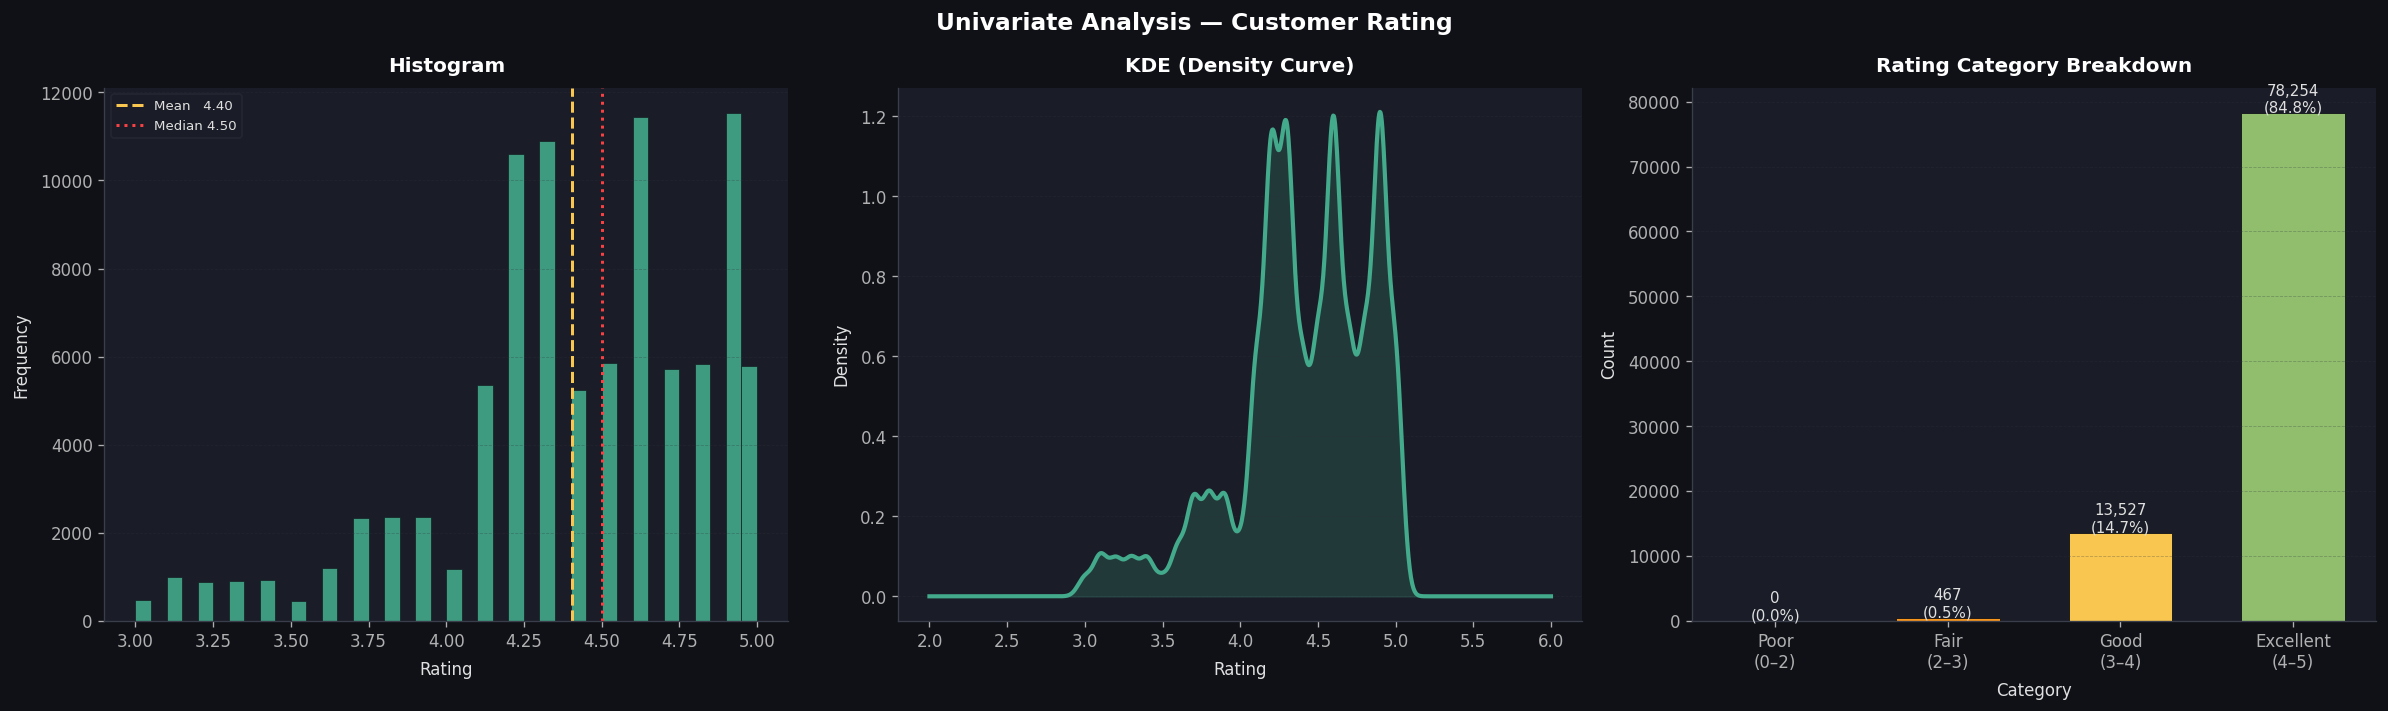


--- Customer Rating Descriptive Statistics ---
count    92248.000
mean         4.404
std          0.438
min          3.000
25%          4.200
50%          4.500
75%          4.800
max          5.000
Skewness  : -0.8851
Kurtosis  : 0.6468


In [11]:
cr = df["Customer Rating"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Customer Rating", fontsize=14, fontweight="bold", color="#ffffff")

axes[0].hist(cr, bins=40, color="#43aa8b", edgecolor="#0f1117", linewidth=0.4, alpha=0.9)
axes[0].axvline(cr.mean(),   color=ACCENT2, linestyle="--", linewidth=1.8, label=f"Mean   {cr.mean():.2f}")
axes[0].axvline(cr.median(), color=DANGER,  linestyle=":",  linewidth=1.8, label=f"Median {cr.median():.2f}")
style_ax(axes[0], "Histogram", "Rating", "Frequency")
axes[0].legend(fontsize=8)

cr.plot(kind="kde", ax=axes[1], color="#43aa8b", linewidth=2.5)
axes[1].fill_between(axes[1].lines[0].get_xdata(),
                     axes[1].lines[0].get_ydata(), alpha=0.2, color="#43aa8b")
style_ax(axes[1], "KDE (Density Curve)", "Rating", "Density")

cat_cr = pd.cut(cr, bins=[0,2,3,4,5], labels=["Poor\n(0–2)","Fair\n(2–3)","Good\n(3–4)","Excellent\n(4–5)"],
                include_lowest=True).value_counts().sort_index()
bars = axes[2].bar(cat_cr.index, cat_cr.values,
                   color=[DANGER,"#f8961e",ACCENT2,SUCCESS],
                   edgecolor="#0f1117", linewidth=0.5, width=0.6)
for bar, v in zip(bars, cat_cr.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{v:,}\n({v/len(cr)*100:.1f}%)", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[2], "Rating Category Breakdown", "Category", "Count")
fig.tight_layout(); plt.show()

print("\n--- Customer Rating Descriptive Statistics ---")
print(cr.describe().round(3).to_string())
print(f"Skewness  : {cr.skew():.4f}")
print(f"Kurtosis  : {cr.kurtosis():.4f}")

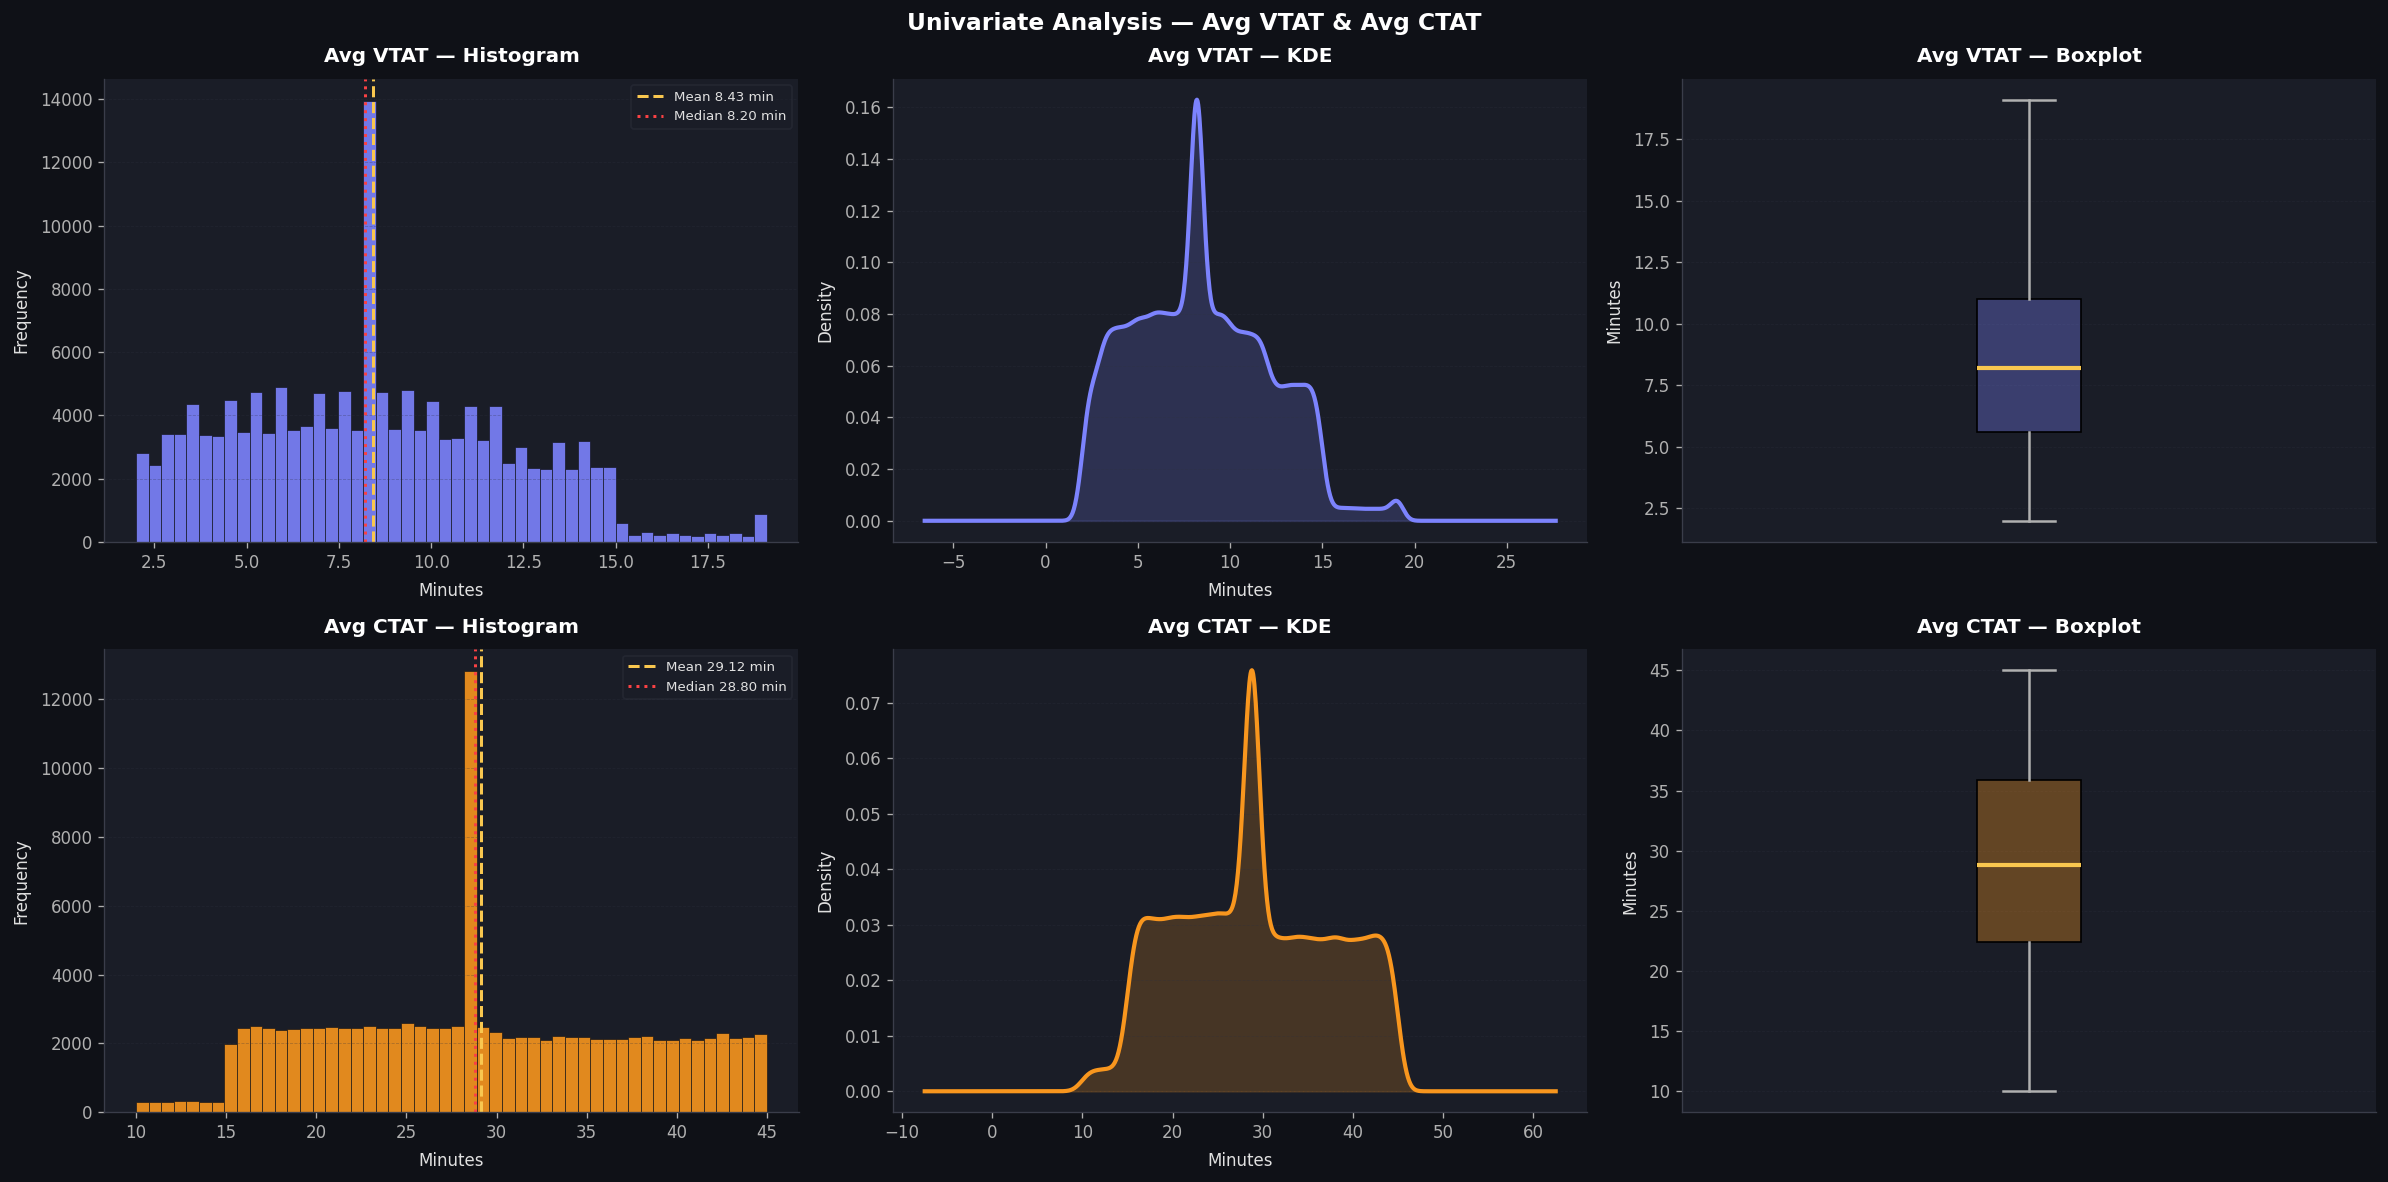


--- Avg VTAT Descriptive Statistics ---
count    148767.000
mean          8.435
std           3.634
min           2.000
25%           5.600
50%           8.200
75%          11.000
max          19.100
Skewness  : 0.3204
Kurtosis  : -0.4572

--- Avg CTAT Descriptive Statistics ---
count    111576.000
mean         29.118
std           8.477
min          10.000
25%          22.400
50%          28.800
75%          35.900
max          45.000
Skewness  : 0.0597
Kurtosis  : -0.9306


In [12]:
vtat = df["Avg VTAT"].dropna()
ctat = df["Avg CTAT"].dropna()

fig, axes = plt.subplots(2, 3, figsize=(20, 10), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Avg VTAT & Avg CTAT", fontsize=14, fontweight="bold", color="#ffffff")

for row, col_data, col_name, color in zip([0,1], [vtat, ctat], ["Avg VTAT","Avg CTAT"], [ACCENT,"#f8961e"]):
    axes[row,0].hist(col_data, bins=50, color=color, edgecolor="#0f1117", linewidth=0.4, alpha=0.9)
    axes[row,0].axvline(col_data.mean(),   color=ACCENT2, linestyle="--", linewidth=1.8,
                        label=f"Mean {col_data.mean():.2f} min")
    axes[row,0].axvline(col_data.median(), color=DANGER,  linestyle=":",  linewidth=1.8,
                        label=f"Median {col_data.median():.2f} min")
    style_ax(axes[row,0], f"{col_name} — Histogram", "Minutes", "Frequency")
    axes[row,0].legend(fontsize=8)

    col_data.plot(kind="kde", ax=axes[row,1], color=color, linewidth=2.5)
    axes[row,1].fill_between(axes[row,1].lines[0].get_xdata(),
                             axes[row,1].lines[0].get_ydata(), alpha=0.2, color=color)
    style_ax(axes[row,1], f"{col_name} — KDE", "Minutes", "Density")

    axes[row,2].boxplot(col_data, vert=True, patch_artist=True,
                        medianprops=dict(color=ACCENT2, linewidth=2.5),
                        boxprops=dict(facecolor=color+"55"),
                        whiskerprops=dict(color="#b0b0b0", linewidth=1.5),
                        capprops=dict(color="#b0b0b0", linewidth=1.5),
                        flierprops=dict(marker=".", alpha=0.2, color=DANGER, markersize=3))
    style_ax(axes[row,2], f"{col_name} — Boxplot", "", "Minutes")
    axes[row,2].set_xticks([])

fig.tight_layout(); plt.show()

for label, col_data in [("VTAT", vtat), ("CTAT", ctat)]:
    print(f"\n--- Avg {label} Descriptive Statistics ---")
    print(col_data.describe().round(3).to_string())
    print(f"Skewness  : {col_data.skew():.4f}")
    print(f"Kurtosis  : {col_data.kurtosis():.4f}")

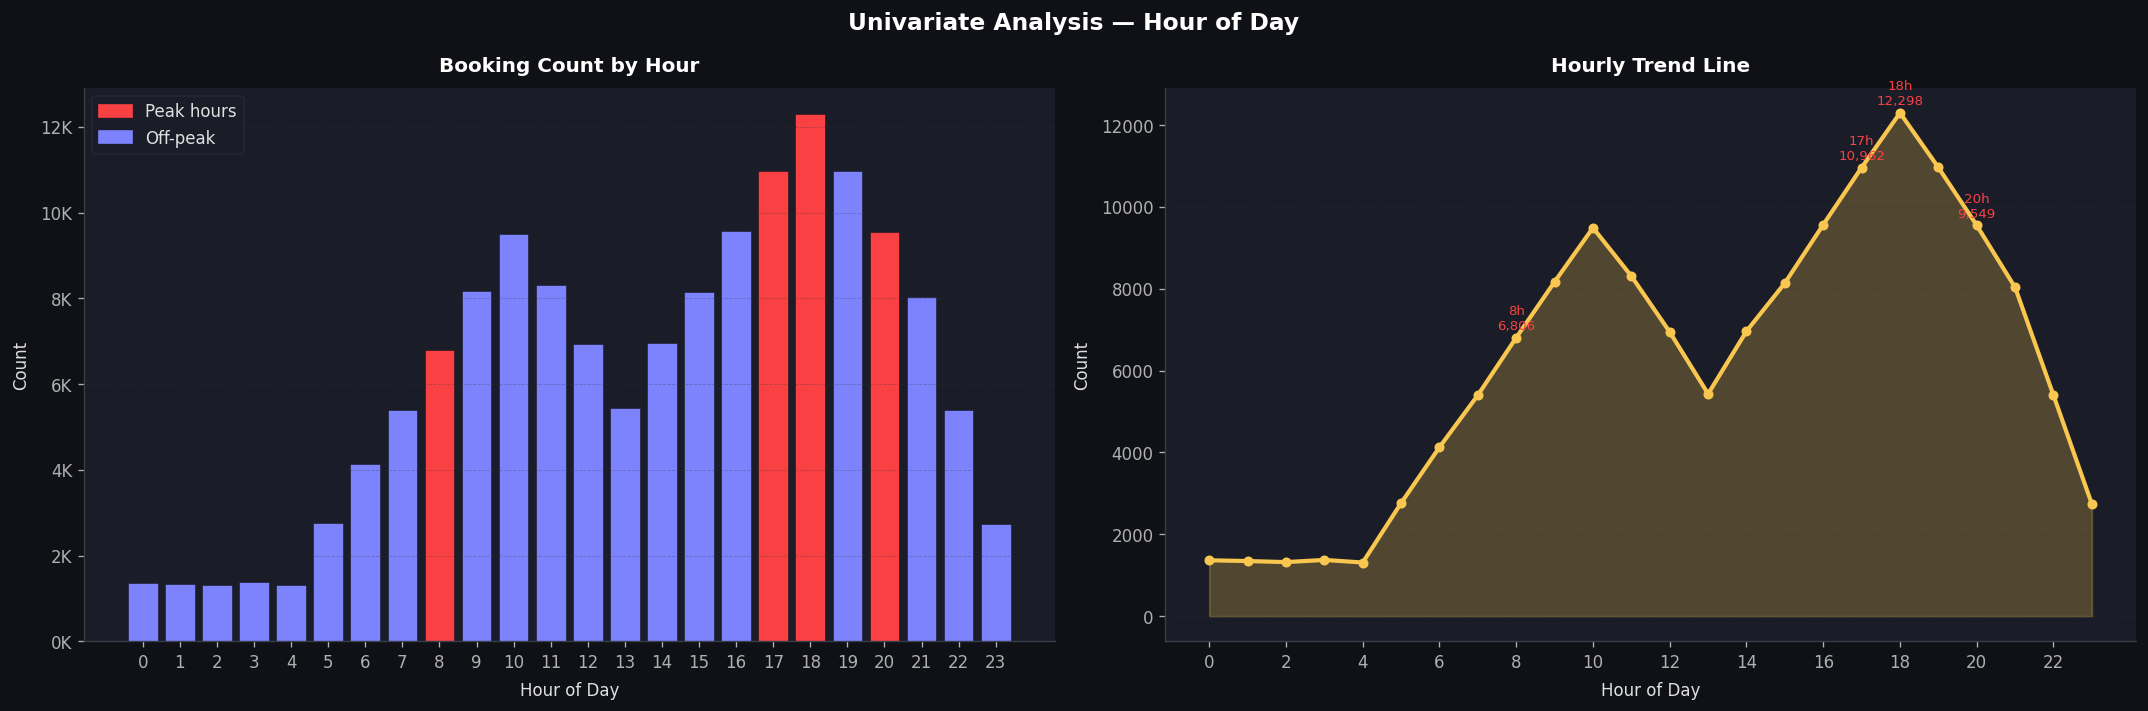


Peak hour   : 18:00  (12,298 bookings)
Lowest hour : 4:00  (1,311 bookings)

Hourly distribution:
Hour
0      1365
1      1347
2      1321
3      1374
4      1311
5      2764
6      4129
7      5401
8      6806
9      8170
10     9490
11     8309
12     6943
13     5431
14     6963
15     8139
16     9565
17    10962
18    12298
19    10963
20     9549
21     8031
22     5397
23     2739


In [13]:
hourly = df["Hour"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Hour of Day", fontsize=14, fontweight="bold", color="#ffffff")

bar_colors = ["#f94144" if h in [8,17,18,20] else ACCENT for h in hourly.index]
bars = axes[0].bar(hourly.index, hourly.values, color=bar_colors,
                   edgecolor="#0f1117", linewidth=0.3, width=0.8)
style_ax(axes[0], "Booking Count by Hour", "Hour of Day", "Count")
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=DANGER,label="Peak hours"),
                         Patch(color=ACCENT,label="Off-peak")], loc="upper left")

axes[1].fill_between(hourly.index, hourly.values, alpha=0.25, color=ACCENT2)
axes[1].plot(hourly.index, hourly.values, color=ACCENT2, linewidth=2.5, marker="o", ms=5)
for peak in [8, 17, 18, 20]:
    axes[1].annotate(f"{peak}h\n{hourly[peak]:,}",
                     xy=(peak, hourly[peak]),
                     xytext=(peak, hourly[peak]+200),
                     fontsize=8, color=DANGER, ha="center")
style_ax(axes[1], "Hourly Trend Line", "Hour of Day", "Count")
axes[1].set_xticks(range(0, 24, 2))
fig.tight_layout(); plt.show()

print(f"\nPeak hour   : {hourly.idxmax()}:00  ({hourly.max():,} bookings)")
print(f"Lowest hour : {hourly.idxmin()}:00  ({hourly.min():,} bookings)")
print(f"\nHourly distribution:\n{hourly.to_string()}")

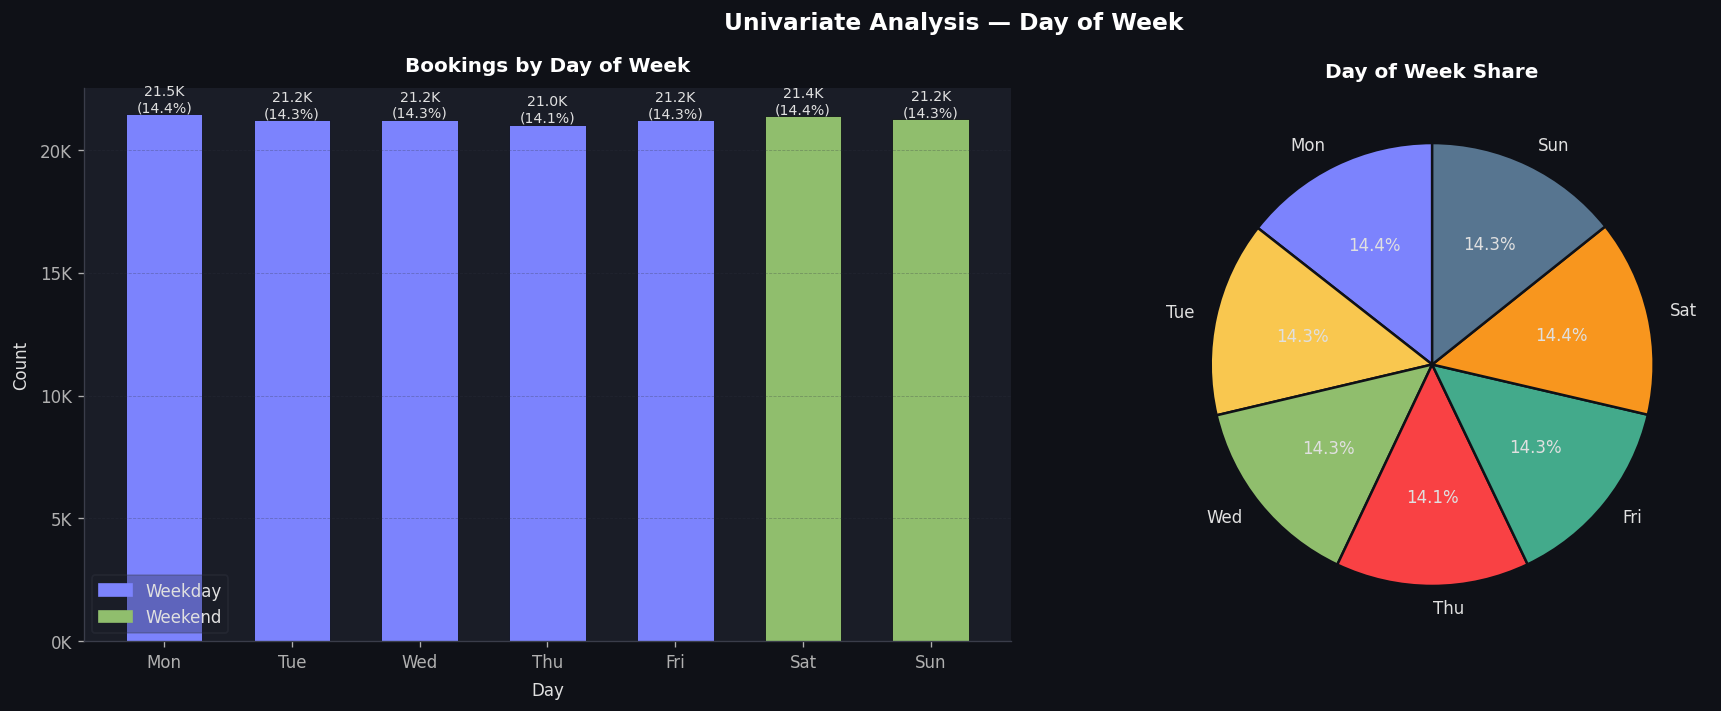


Busiest day : Mon  (21,460 bookings)
Quietest day: Thu  (21,033 bookings)

Mon    21460
Tue    21214
Wed    21229
Thu    21033
Fri    21222
Sat    21363
Sun    21246


In [14]:
day_names  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily      = df["DayOfWeek"].value_counts().sort_index()
daily.index = day_names

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Day of Week", fontsize=14, fontweight="bold", color="#ffffff")

colors = [SUCCESS if i >= 5 else ACCENT for i in range(7)]
bars = axes[0].bar(daily.index, daily.values, color=colors,
                   edgecolor="#0f1117", linewidth=0.5, width=0.6)
for bar, val in zip(bars, daily.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{val/1000:.1f}K\n({val/len(df)*100:.1f}%)",
                 ha="center", fontsize=8.5, color="#e0e0e0")
style_ax(axes[0], "Bookings by Day of Week", "Day", "Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
from matplotlib.patches import Patch as P
axes[0].legend(handles=[P(color=ACCENT,label="Weekday"), P(color=SUCCESS,label="Weekend")])

axes[1].pie(daily.values, labels=daily.index, colors=PALETTE[:7],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[1].set_title("Day of Week Share", color="#ffffff", fontweight="bold")
fig.tight_layout(); plt.show()

print(f"\nBusiest day : {daily.idxmax()}  ({daily.max():,} bookings)")
print(f"Quietest day: {daily.idxmin()}  ({daily.min():,} bookings)")
print(f"\n{daily.to_string()}")

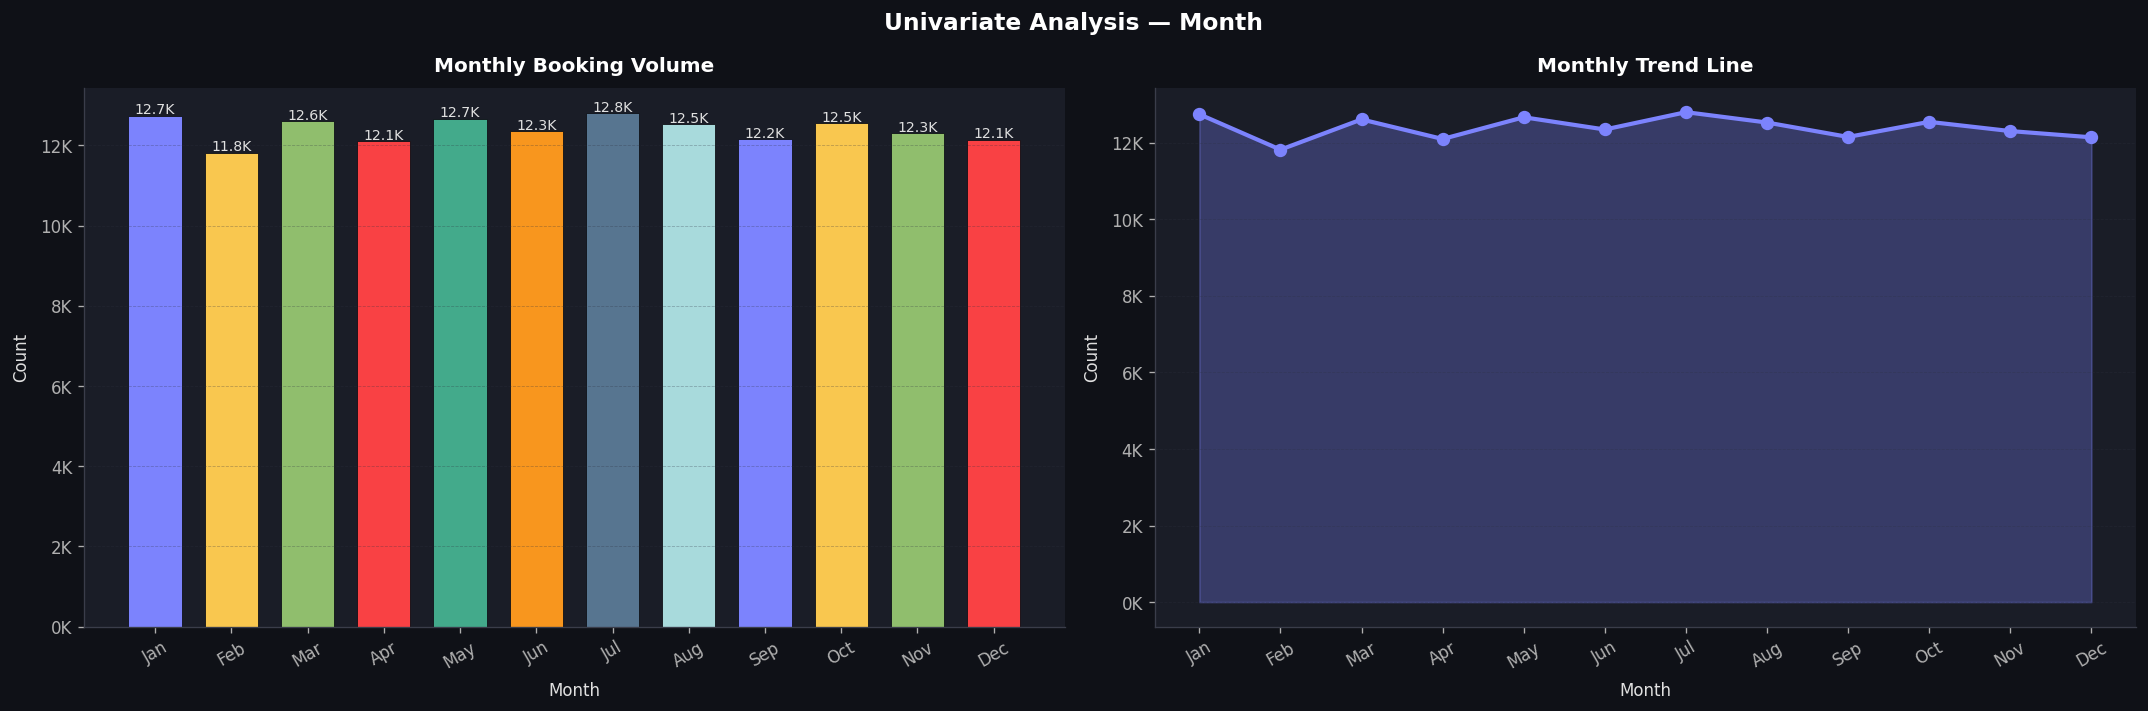


Busiest month : Jul  (12,800 bookings)
Slowest month : Feb  (11,820 bookings)

Jan    12745
Feb    11820
Mar    12611
Apr    12099
May    12667
Jun    12347
Jul    12800
Aug    12529
Sep    12153
Oct    12547
Nov    12306
Dec    12143


In [15]:
months     = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly    = df["Month"].value_counts().sort_index()
monthly.index = months

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Month", fontsize=14, fontweight="bold", color="#ffffff")

bars = axes[0].bar(monthly.index, monthly.values, color=PALETTE[:12],
                   edgecolor="#0f1117", linewidth=0.5, width=0.7)
for bar, val in zip(bars, monthly.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f"{val/1000:.1f}K", ha="center", fontsize=8.5, color="#e0e0e0")
style_ax(axes[0], "Monthly Booking Volume", "Month", "Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[0].tick_params(axis="x", rotation=30)

axes[1].fill_between(range(12), monthly.values, alpha=0.3, color=ACCENT)
axes[1].plot(range(12), monthly.values, color=ACCENT, linewidth=2.5, marker="o", ms=7)
axes[1].set_xticks(range(12)); axes[1].set_xticklabels(months)
style_ax(axes[1], "Monthly Trend Line", "Month", "Count")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout(); plt.show()

print(f"\nBusiest month : {monthly.idxmax()}  ({monthly.max():,} bookings)")
print(f"Slowest month : {monthly.idxmin()}  ({monthly.min():,} bookings)")
print(f"\n{monthly.to_string()}")

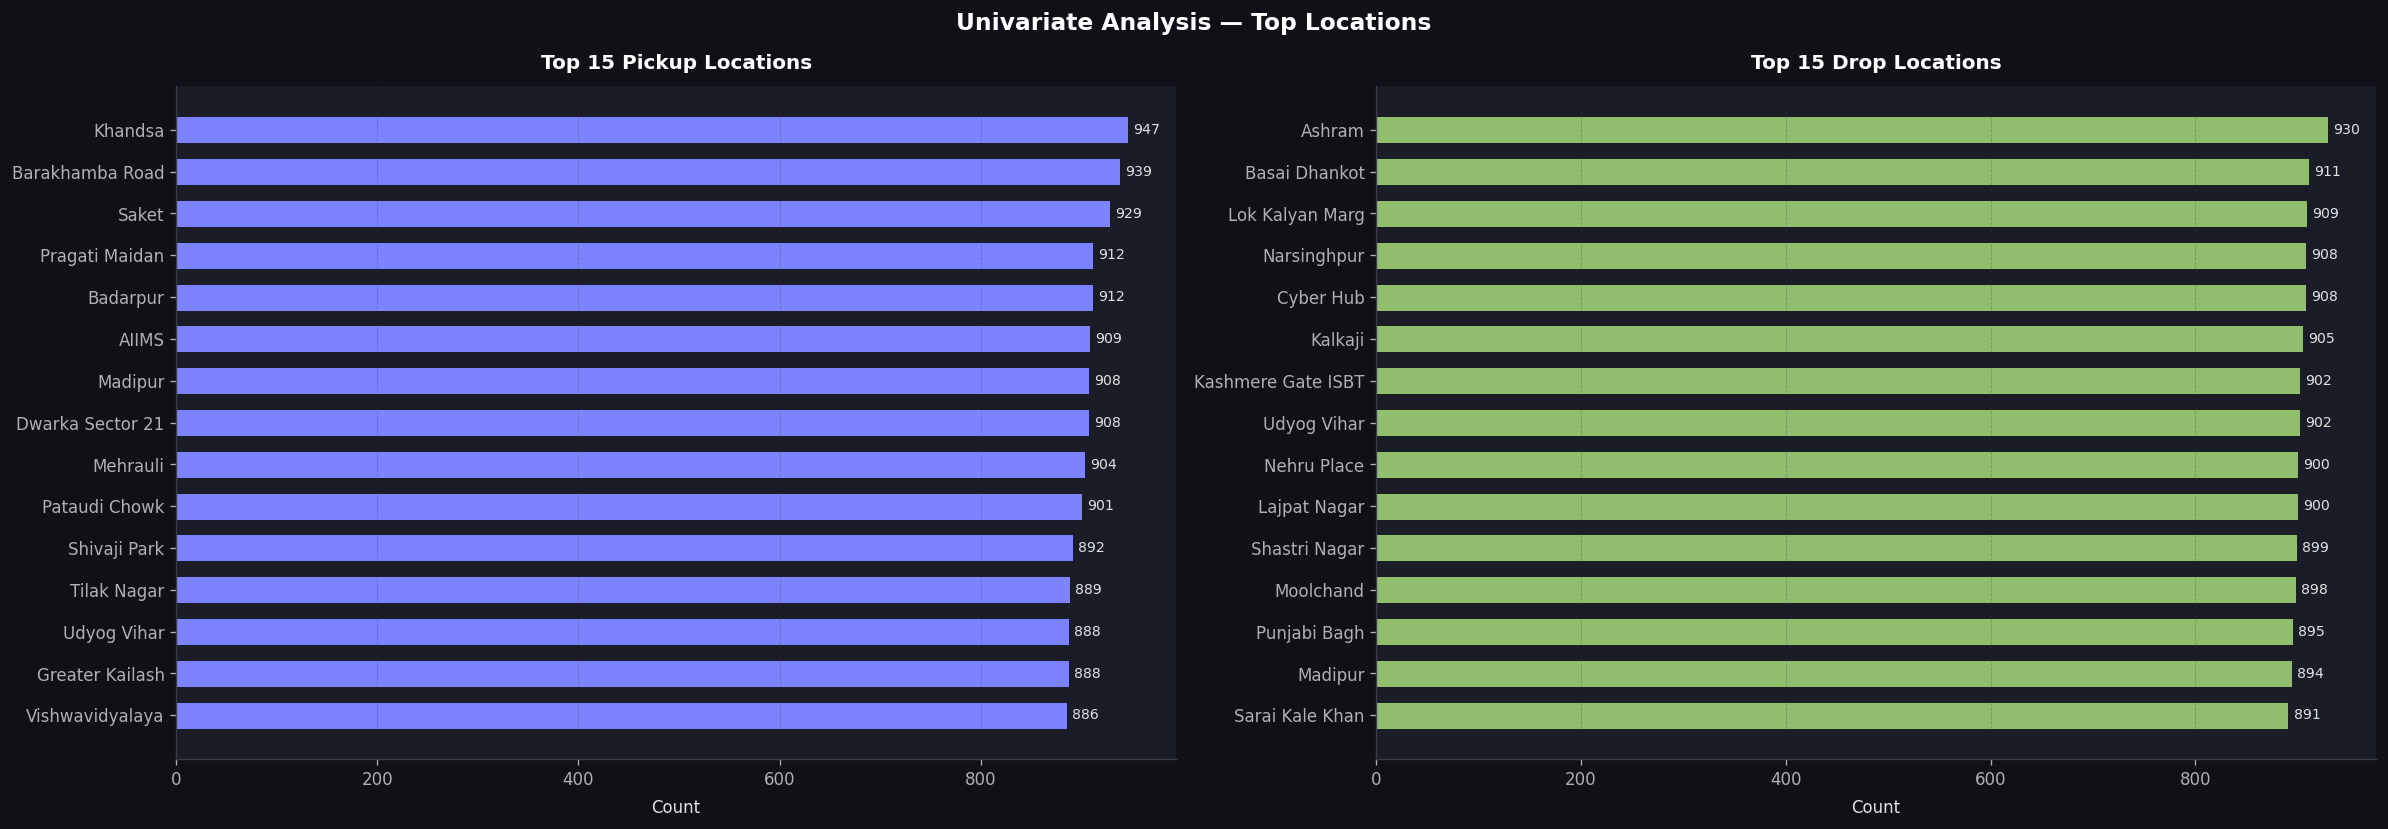

Unique Pickup Locations : 176
Unique Drop Locations   : 176

Top 5 Pickup:
Pickup Location
Khandsa            947
Barakhamba Road    939
Saket              929
Pragati Maidan     912
Badarpur           912

Top 5 Drop:
Drop Location
Ashram             930
Basai Dhankot      911
Lok Kalyan Marg    909
Narsinghpur        908
Cyber Hub          908


In [16]:
top_pickup = df["Pickup Location"].value_counts().head(15)
top_drop   = df["Drop Location"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Top Locations", fontsize=14, fontweight="bold", color="#ffffff")

for ax, data, title, color in zip(axes,
    [top_pickup, top_drop],
    ["Top 15 Pickup Locations","Top 15 Drop Locations"],
    [ACCENT, SUCCESS]):
    bars = ax.barh(data.index[::-1], data.values[::-1],
                   color=color, edgecolor="#0f1117", linewidth=0.5, height=0.65)
    for bar, v in zip(bars, data.values[::-1]):
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                f"{v:,}", va="center", fontsize=8.5, color="#e0e0e0")
    style_ax(ax, title, "Count", "", grid="x")
fig.tight_layout(); plt.show()

print(f"Unique Pickup Locations : {df['Pickup Location'].nunique()}")
print(f"Unique Drop Locations   : {df['Drop Location'].nunique()}")
print(f"\nTop 5 Pickup:\n{top_pickup.head().to_string()}")
print(f"\nTop 5 Drop:\n{top_drop.head().to_string()}")

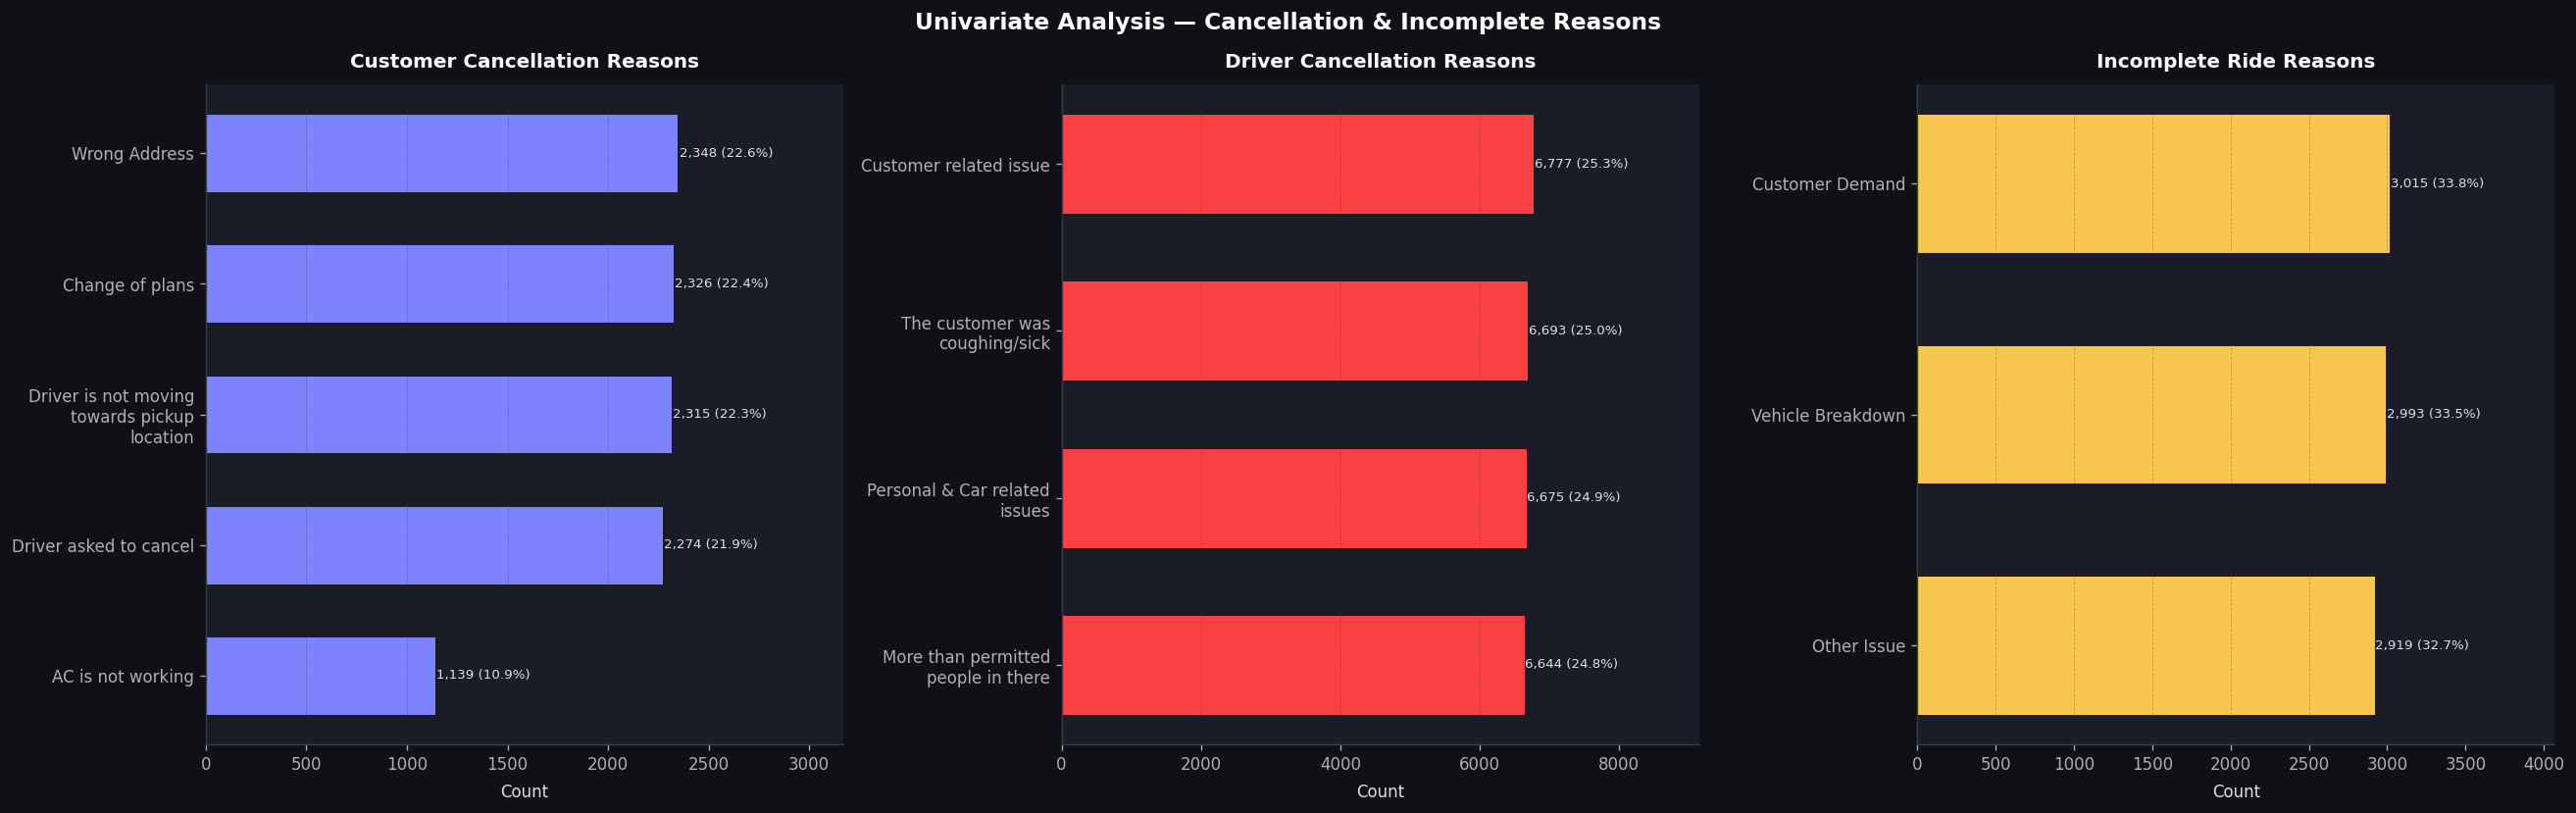


Top Customer Cancel Reason : Wrong Address  (2,348)
Top Driver Cancel Reason   : Customer related issue  (6,777)
Top Incomplete Reason      : Customer Demand  (3,015)


In [17]:
cust_cancel = df["Reason for cancelling by Customer"].dropna().value_counts()
driv_cancel = df["Driver Cancellation Reason"].dropna().value_counts()
incomp_r    = df["Incomplete Rides Reason"].dropna().value_counts()

import textwrap

fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor="#0f1117")
fig.suptitle("Univariate Analysis — Cancellation & Incomplete Reasons",
             fontsize=14, fontweight="bold", color="#ffffff")

for ax, data, title, color in zip(axes,
    [cust_cancel, driv_cancel, incomp_r],
    ["Customer Cancellation Reasons","Driver Cancellation Reasons","Incomplete Ride Reasons"],
    [ACCENT, DANGER, ACCENT2]):
    wrapped = [textwrap.fill(str(l), 22) for l in data.index]
    bars = ax.barh(wrapped[::-1], data.values[::-1],
                   color=color, edgecolor="#0f1117", linewidth=0.5, height=0.6)
    for bar, v in zip(bars, data.values[::-1]):
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                f"{v:,} ({v/data.sum()*100:.1f}%)", va="center", fontsize=8, color="#e0e0e0")
    style_ax(ax, title, "Count", "", grid="x")
    ax.set_xlim(0, data.max()*1.35)
fig.tight_layout(); plt.show()

print(f"\nTop Customer Cancel Reason : {cust_cancel.index[0]}  ({cust_cancel.iloc[0]:,})")
print(f"Top Driver Cancel Reason   : {driv_cancel.index[0]}  ({driv_cancel.iloc[0]:,})")
print(f"Top Incomplete Reason      : {incomp_r.index[0]}  ({incomp_r.iloc[0]:,})")

In [18]:
num_cols = ["Booking Value","Ride Distance","Driver Ratings","Customer Rating","Avg VTAT","Avg CTAT"]
summary  = df[num_cols].describe().T.round(2)
summary["skewness"]  = df[num_cols].skew().round(4)
summary["kurtosis"]  = df[num_cols].kurtosis().round(4)
summary["missing_n"] = df[num_cols].isnull().sum()
summary["missing_%"] = (df[num_cols].isnull().mean() * 100).round(2)

print("=" * 80)
print("  FULL DESCRIPTIVE STATISTICS SUMMARY")
print("=" * 80)
display(summary)

print("\n=== OUTLIER COUNT (IQR Method) ===")
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:<25}: {n_out:>5} outliers  ({n_out/df[col].notna().sum()*100:.2f}%)")

  FULL DESCRIPTIVE STATISTICS SUMMARY


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing_n,missing_%
Booking Value,101175.0,492.00,331.73,50.0,234.00,414.00,689.00,1371.5,0.9428,0.2585,47592,31.99
Ride Distance,101175.0,24.64,14.00,1.0,12.46,23.72,36.82,50.0,0.1279,-1.2126,47592,31.99
Driver Ratings,92248.0,4.23,0.44,3.0,4.10,4.30,4.60,5.0,-0.6558,0.2822,56519,37.99
Customer Rating,92248.0,4.40,0.44,3.0,4.20,4.50,4.80,5.0,-0.8851,0.6468,56519,37.99
Avg VTAT,148767.0,8.43,3.63,2.0,5.60,8.20,11.00,19.1,0.3204,-0.4572,0,0.00
Avg CTAT,111576.0,29.12,8.48,10.0,22.40,28.80,35.90,45.0,0.0597,-0.9306,37191,25.00



=== OUTLIER COUNT (IQR Method) ===
  Booking Value            :     0 outliers  (0.00%)
  Ride Distance            :     0 outliers  (0.00%)
  Driver Ratings           :  5162 outliers  (5.60%)
  Customer Rating          :  3237 outliers  (3.51%)
  Avg VTAT                 :     0 outliers  (0.00%)
  Avg CTAT                 :     0 outliers  (0.00%)
